<a href="https://colab.research.google.com/github/aleena-mariya19/python_work/blob/main/geo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: >

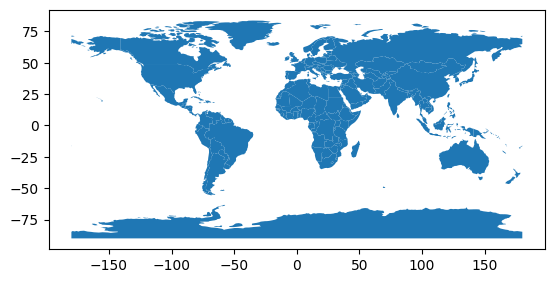

In [1]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world.plot()


In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 3.7 MB/s eta 0:00:00


<Axes: >

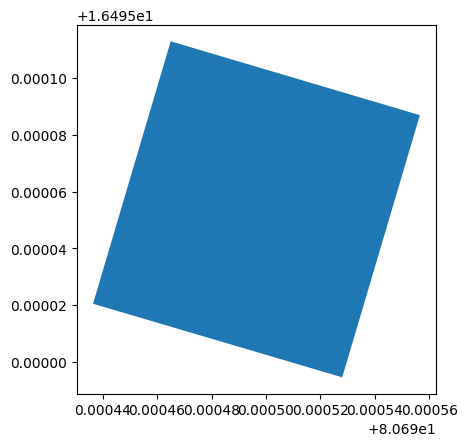

In [4]:

import osmnx as ox

gdf = ox.geocode_to_gdf("Banglore, India")

gdf.plot()

In [5]:
# View first rows
print(gdf.head())

# CRS (coordinate system)
print(gdf.crs)

# Geometry type
print(gdf.geometry.type)

# Columns
print(gdf.columns)

                                            geometry  bbox_west  bbox_south  \
0  POLYGON ((80.69044 16.49502, 80.69053 16.49499...  80.690437   16.494995   

   bbox_east  bbox_north   place_id osm_type     osm_id        lat        lon  \
0  80.690556   16.495113  411285967      way  403292376  16.495054  80.690496   

      class        type  place_rank  importance addresstype  name  \
0  building  commercial          30    0.000059    building  tree   

                                        display_name  
0  tree, slv banglore cake house, MDR0164, Kanuru...  
epsg:4326
0    Polygon
dtype: object
Index(['geometry', 'bbox_west', 'bbox_south', 'bbox_east', 'bbox_north',
       'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type',
       'place_rank', 'importance', 'addresstype', 'name', 'display_name'],
      dtype='object')


In [6]:
# Project to UTM (meters)
gdf_proj = gdf.to_crs(epsg=32643)   # UTM zone for Delhi

# Area (in sq km)
gdf_proj["area_sqkm"] = gdf_proj.area / 1e6

# Perimeter (in km)
gdf_proj["perimeter_km"] = gdf_proj.length / 1000

print(gdf_proj[["area_sqkm", "perimeter_km"]])


   area_sqkm  perimeter_km
0   0.000109      0.041866


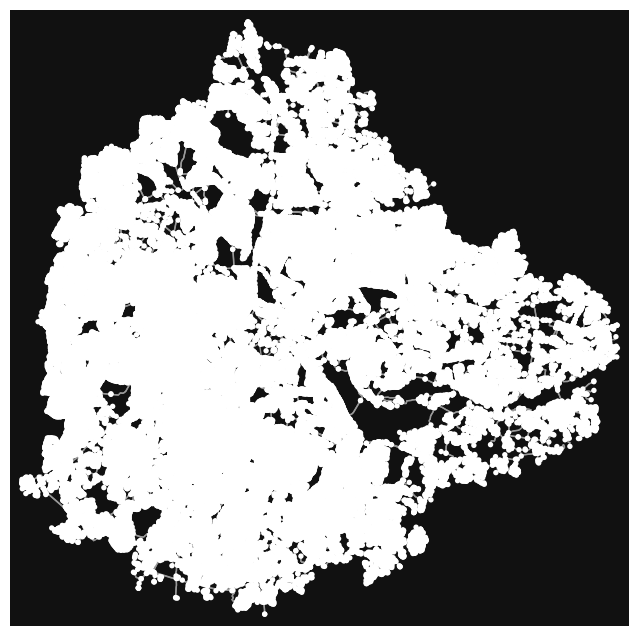

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
# Download road network
G = ox.graph_from_place("Bangalore, Karnataka, India", network_type="drive")

# Plot roads
ox.plot_graph(G)

In [9]:
stats = ox.basic_stats(G)

for k, v in stats.items():
    print(k, ":", v)


n : 154530
m : 392447
k_avg : 5.079233805733515
edge_length_total : 24216714.80979778
edge_length_avg : 61.706968864070255
streets_per_node_avg : 2.649097262667443
streets_per_node_counts : {0: 0, 1: 37620, 2: 132, 3: 95766, 4: 20881, 5: 127, 6: 4}
streets_per_node_proportions : {0: 0.0, 1: 0.24344787419918462, 2: 0.0008542030673655601, 3: 0.6197243253737138, 4: 0.13512586552772923, 5: 0.0008218468905714101, 6: 2.5884941435320002e-05}
intersection_count : 116910
street_length_total : 12960360.28618863
street_segment_count : 204419
street_length_avg : 63.400957279844974
circuity_avg : 1.03000984551549
self_loop_proportion : 0.00028862287752116976


Number of buildings: 1


<Axes: >

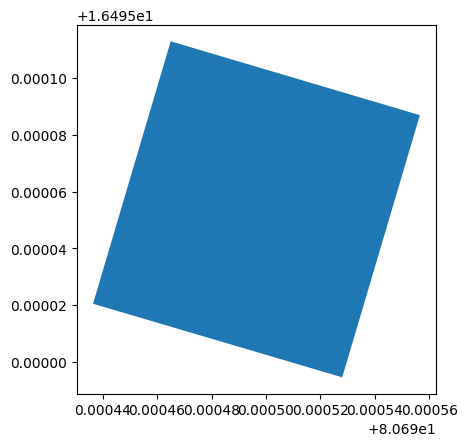

In [11]:
from shapely.geometry import Polygon

# Get polygon
polygon = gdf.geometry.iloc[0]

# Download buildings
buildings = ox.features_from_polygon(
    polygon,
    tags={"building": True}
)

print("Number of buildings:", len(buildings))

buildings.plot()


In [12]:
area = gdf_proj["area_sqkm"].iloc[0]

density = len(buildings) / area

print("Building Density per sq km:", density)

Building Density per sq km: 9133.57200032139


/tmp/ipython-input-2875574209.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.centroid


<Axes: >

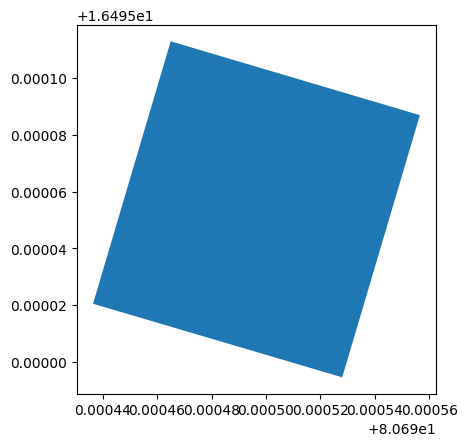

In [13]:
# Count buildings per ward (if available)
buildings["centroid"] = buildings.centroid

buildings.plot(markersize=1)


In [15]:
# The original polygon was generated from a misspelled location "Banglore, India"
# which resulted in a very small, specific feature (like a single building or a tree).
# Landuse data is typically associated with larger areas.

# To correctly retrieve landuse data for Bangalore, we need a polygon that represents
# the city of Bangalore. We will re-geocode here to obtain such a polygon.
import osmnx as ox
new_gdf = ox.geocode_to_gdf("Bangalore, Karnataka, India")
corrected_polygon = new_gdf.geometry.iloc[0]

landuse = ox.features_from_polygon(
    corrected_polygon, # Use the corrected polygon
    tags={"landuse": True}
)

print("Number of landuse features:", len(landuse))
landuse["landuse"].value_counts()

Number of landuse features: 14430


,count
landuse,
residential,7145
commercial,2352
construction,1130
industrial,645
grass,474
recreation_ground,418
orchard,411
retail,383
farmland,353


Number of parks found: 1726


<Axes: >

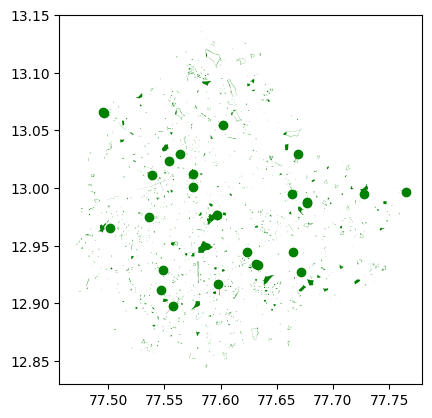

In [17]:
green = ox.features_from_polygon(
    corrected_polygon, # Use the corrected polygon
    tags={"leisure": "park"}
)

print("Number of parks found:", len(green))
green.plot(color="green")

In [18]:
# Convert geometry to centroids
buildings["centroid"] = buildings.geometry.centroid

# Extract lat/lon
buildings["lat"] = buildings.centroid.y
buildings["lon"] = buildings.centroid.x

/tmp/ipython-input-3882717123.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.geometry.centroid
/tmp/ipython-input-3882717123.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lat"] = buildings.centroid.y
/tmp/ipython-input-3882717123.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lon"] = buildings.centroid.x


In [19]:
buildings_tabular = buildings.drop(columns=["geometry", "centroid"])

In [20]:
buildings_tabular.to_excel("Banglore_buildings.xlsx", index=False)

In [23]:
from google.colab import files
files.download("Banglore_buildings.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>